# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.multiclass  import OneVsRestClassifier
import joblib



## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')
df.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21
)

In [4]:
#checking distribution 

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

dayofweek
3    0.232196
6    0.212908
1    0.164688
5    0.160237
2    0.092730
0    0.077893
4    0.059347
Name: proportion, dtype: float64
dayofweek
3    0.245562
6    0.204142
5    0.162722
1    0.153846
0    0.091716
4    0.071006
2    0.071006
Name: proportion, dtype: float64


In [5]:
# stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

In [6]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

dayofweek
3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: proportion, dtype: float64
dayofweek
3    0.236686
6    0.210059
1    0.162722
5    0.159763
2    0.088757
0    0.079882
4    0.062130
Name: proportion, dtype: float64


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [7]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_logreg = accuracy_score(y_test, y_pred)
print("LogReg accuracy:", acc_logreg)

LogReg accuracy: 0.6331360946745562


### b. SVM

In [8]:
model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred)
print("SVM accuracy:", acc_svm)

SVM accuracy: 0.8461538461538461


### c. Decision tree

In [9]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred)
print("Tree accuracy:", acc_tree)

Tree accuracy: 0.8698224852071006


### d. Random forest

In [10]:
model = RandomForestClassifier(random_state=21)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred)
print("Random Forest accuracy:", acc_rf)

Random Forest accuracy: 0.9378698224852071


The models show different accuracies: Random Forest (~0.94) is highest, then Decision Tree (~0.87), SVM (~0.85), and Logistic Regression (~0.63).

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [11]:
model = OneVsRestClassifier(
    LogisticRegression(solver='liblinear')
)
scores = cross_val_score(model, X, y, cv=10)

print("LogReg mean:", np.mean(scores))
print("LogReg std:", np.std(scores))

LogReg mean: 0.45649126514511124
LogReg std: 0.16478021442150131


In [12]:
model = SVC()

scores = cross_val_score(model, X, y, cv=10)

print("SVM mean:", np.mean(scores))
print("SVM std:", np.std(scores))

SVM mean: 0.6122182304874613
SVM std: 0.1737022906791198


### b. SVM

In [13]:
model = DecisionTreeClassifier()

scores = cross_val_score(model, X, y, cv=10)

print("Tree mean:", np.mean(scores))
print("Tree std:", np.std(scores))

Tree mean: 0.5955409974640744
Tree std: 0.16469494683966218


### c. Decision tree

In [14]:
model = RandomForestClassifier(random_state=21)

scores = cross_val_score(model, X, y, cv=10)

print("RF mean:", np.mean(scores))
print("RF std:", np.std(scores))

RF mean: 0.6602035784728091
RF std: 0.16595229084444318


### d. Random forest

In [15]:
model = RandomForestClassifier(random_state=21)

scores = cross_val_score(model, X, y, cv=10)

print("RF mean:", np.mean(scores))
print("RF std:", np.std(scores))

RF mean: 0.6602035784728091
RF std: 0.16595229084444318


## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=21
)

scores = cross_val_score(model, X, y, cv=5)
print(np.mean(scores))

0.5024283180868435


In [17]:

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Final accuracy:", accuracy_score(y_test, y_pred))

Final accuracy: 0.8461538461538461


<Axes: ylabel='feature'>

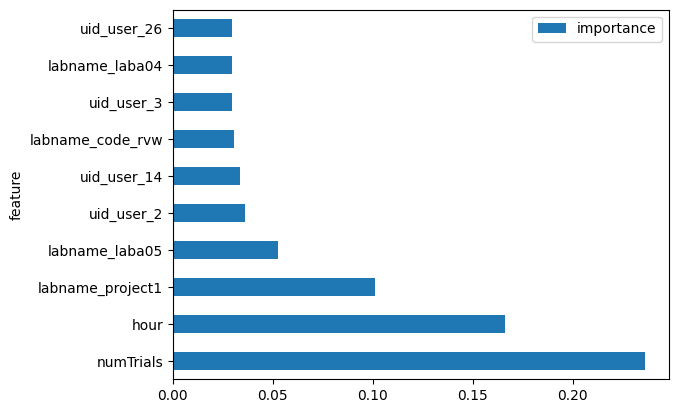

In [18]:
importances = model.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(10)

df_imp.plot(kind='barh', x='feature', y='importance')

In [19]:
joblib.dump(model, 'rf_model.pkl')

['rf_model.pkl']

In [20]:
model_loaded = joblib.load('rf_model.pkl')

y_pred = model_loaded.predict(X_test)
print("Loaded model accuracy:", accuracy_score(y_test, y_pred))

Loaded model accuracy: 0.8461538461538461
